Baixando dados reais de BTC-USD até 2026-04-01...
Baixando dados macro (IBOV e Dólar)...

Dados separados! Treino: 3349 dias | Teste: 838 dias.
Otimizando hiperparâmetros do modelo (Isso leva alguns segundos)...

RESULTADO DO BACKTEST (Set de Teste)
  RMSE LightGBM : 0.06708 (Previsão via Delta)
  RMSE Baseline : 0.08567 (Média Móvel)
  MAPE          : 13.62%

A PREVISÃO DO FUTURO
  Data Base                 : 2026-03-31
  Volatilidade Atual        : 34.6% a.a.
  Previsão para daqui 5 dias: 36.9% a.a.



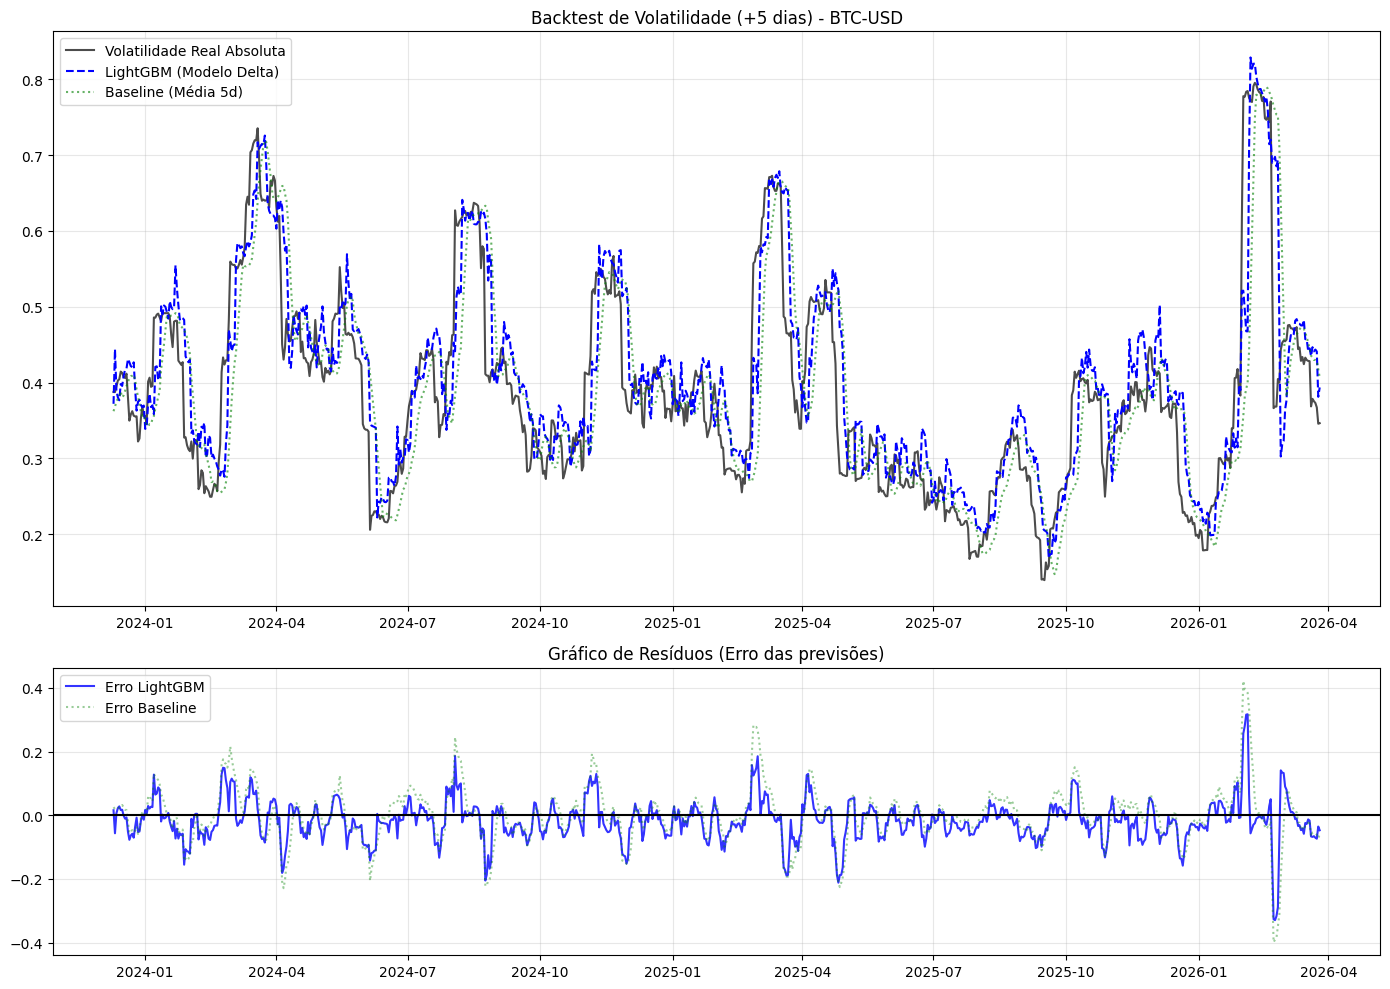

Modelo exportado com sucesso para 'lightgbm_model.joblib'!


In [5]:
# -*- coding: utf-8 -*-
"""TesteBaseline.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1hH0zWyj5C_SID8uillwaJ6luyQ5ol97t
"""

!pip install optuna

import yfinance as yf
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import joblib

warnings.filterwarnings('ignore')

# 1. CONFIGURAÇÕES INICIAIS
TICKER = 'BTC-USD'
WINDOW = 21 # Janela de volatilidade
START_DATE = '2014-09-17'

#Data de "Hoje"
#END_DATE = datetime.today().strftime('%Y-%m-%d')
#Data teste
END_DATE = '2026-04-01'

def fetch_and_prepare_data(ticker):
    print(f"Baixando dados reais de {ticker} até {END_DATE}...")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # 1. Retornos e Target Absoluto
    df['returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['target_vol'] = df['returns'].rolling(window=WINDOW).std() * np.sqrt(252)
    df['target_vol_future'] = df['target_vol'].shift(-5)

    # ====================================================================
    # A SOLUÇÃO: CRIANDO O DELTA AQUI!
    # O modelo vai aprender a prever a VARIAÇÃO, não o valor absoluto.
    # ====================================================================
    df['target_delta'] = df['target_vol_future'] - df['target_vol']

    # 2. Features Base
    df['lag_vol_1'] = df['target_vol'].shift(1)
    df['lag_vol_5'] = df['target_vol'].shift(5)
    df['returns_sq'] = df['returns']**2
    df['ema_returns'] = df['returns'].ewm(span=WINDOW).mean()

    rs = (1.0 / (4.0 * np.log(2.0))) * (np.log(df['High'] / df['Low']) ** 2)
    df['parkinson_vol'] = np.sqrt(rs.rolling(window=WINDOW).mean()) * np.sqrt(252)

    df['vol_media_5d'] = df['target_vol'].rolling(window=5).mean()
    df['vol_media_21d'] = df['target_vol'].rolling(window=21).mean()
    df['vol_media_63d'] = df['target_vol'].rolling(window=63).mean()

    df['skew_21'] = df['returns'].rolling(window=WINDOW).skew()
    df['kurt_21'] = df['returns'].rolling(window=WINDOW).kurt()

    # 3. Macroeconomia
    print("Baixando dados macro (IBOV e Dólar)...")
    macro_data = yf.download(['^BVSP', 'BRL=X'], start=START_DATE, end=END_DATE, progress=False)['Close']

    df['retorno_ibov'] = np.log(macro_data['^BVSP'] / macro_data['^BVSP'].shift(1))
    df['retorno_dolar'] = np.log(macro_data['BRL=X'] / macro_data['BRL=X'].shift(1))

    df['retorno_ibov'] = df['retorno_ibov'].fillna(0)
    df['retorno_dolar'] = df['retorno_dolar'].fillna(0)

    # 4. Indicadores Técnicos
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df['rsi_14'] = 100 - (100 / (1 + (gain / loss)))

    bb_media = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['bb_distancia_topo'] = (bb_media + (2 * bb_std)) - df['Close']

    # Limpeza final (Agora com o target_delta existindo!)
    features_obrigatorias = ['lag_vol_1', 'parkinson_vol', 'kurt_21', 'retorno_ibov', 'rsi_14', 'bb_distancia_topo']
    df_features_prontas = df.dropna(subset=features_obrigatorias)

    return df_features_prontas

# 2. PREPARAÇÃO DE TREINO, TESTE E O "FUTURO DESCONHECIDO"

df_model = fetch_and_prepare_data(TICKER)

features = [
    'target_vol', # <--- AQUI ESTAVA O SEU MAIOR ERRO. O modelo precisa saber o hoje!
    'lag_vol_1', 'lag_vol_5', 'returns_sq', 'ema_returns',
    'parkinson_vol', 'vol_media_5d', 'vol_media_21d',
    'vol_media_63d', 'skew_21', 'kurt_21',
    'retorno_ibov', 'retorno_dolar', 'rsi_14', 'bb_distancia_topo'
]

# Separamos os dados em duas caixas:
# 1. Histórico: Onde temos o target do futuro preenchido (dá pra treinar/testar)
df_historico = df_model.dropna(subset=['target_vol_future'])

# 2. O Futuro Real: Os últimos 5 dias do dataset. Eles têm features, mas o
# 'target_vol_future' é NaN (porque o futuro ainda não aconteceu!).
df_futuro_real = df_model[df_model['target_vol_future'].isna()]

X = df_historico[features]
y = df_historico['target_delta']

# Divisão de 80% Treino / 20% Teste (sem embaralhar, respeitando a linha do tempo)
split_idx = int(len(df_historico) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nDados separados! Treino: {len(X_train)} dias | Teste: {len(X_test)} dias.")

# 3. OTIMIZAÇÃO COM OPTUNA E TIMESERIESSPLIT
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 64),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    tscv = TimeSeriesSplit(n_splits=5)
    errors = []

    for train_index, val_index in tscv.split(X_train):
        X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
        y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]

        gbm = lgb.LGBMRegressor(**param)

        # O early_stopping avisa a hora certa de parar para não decorar os dados (Overfitting)
        callbacks = [lgb.early_stopping(stopping_rounds=30, verbose=False)]
        gbm.fit(X_t, y_t, eval_set=[(X_v, y_v)], callbacks=callbacks)

        preds = gbm.predict(X_v)
        errors.append(np.sqrt(mean_squared_error(y_v, preds)))

    return np.mean(errors)

# Executa a busca pelos melhores parâmetros (reduzido para 20 pra rodar rápido ao vivo)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Otimizando hiperparâmetros do modelo (Isso leva alguns segundos)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# 4. TREINO FINAL E TRAVAS DE SEGURANÇA (O Clip)

best_params = study.best_params
model = lgb.LGBMRegressor(**best_params)
model.fit(X_train, y_train)

# CORREÇÃO 1: O limite máximo deve ser calculado sobre os valores ABSOLUTOS do histórico
limite_maximo_vol = np.percentile(df_historico['target_vol_future'], 97)

# 5. AVALIAÇÃO DO MODELO NO PASSADO RECENTE (O Backtest)

# O modelo cospe as variações (deltas)
pred_deltas = model.predict(X_test)

# A previsão final é a vol atual + o delta previsto
test_preds = X_test['target_vol'].values + pred_deltas

# Trava as previsões dentro de limites realistas (1% no mínimo, e o novo teto corrigido)
test_preds = np.clip(test_preds, 0.01, limite_maximo_vol)

# CORREÇÃO 2: Recriando o valor absoluto real do teste para o RMSE e para o Gráfico
y_test_absoluto = X_test['target_vol'].values + y_test.values

final_rmse = np.sqrt(mean_squared_error(y_test_absoluto, test_preds))
final_mape = mean_absolute_percentage_error(y_test_absoluto, test_preds)

# Baseline: Prever que o futuro será igual à média dos últimos 5 dias
baseline_preds = X_test['vol_media_5d'].values
baseline_rmse = np.sqrt(mean_squared_error(y_test_absoluto, baseline_preds))

print(f"\n===============================================")
print(f"RESULTADO DO BACKTEST (Set de Teste)")
print(f"===============================================")
print(f"  RMSE LightGBM : {final_rmse:.5f} (Previsão via Delta)")
print(f"  RMSE Baseline : {baseline_rmse:.5f} (Média Móvel)")
print(f"  MAPE          : {final_mape*100:.2f}%")

# 6. A PREVISÃO DO FUTURO
ultima_linha = df_futuro_real.tail(1)
data_base = ultima_linha.index[0].strftime('%Y-%m-%d')
volatilidade_hoje = ultima_linha['target_vol'].values[0]

delta_futuro = model.predict(ultima_linha[features])[0]
previsao_futura = np.clip((volatilidade_hoje + delta_futuro), 0.01, limite_maximo_vol)

print(f"\n===============================================")
print(f"A PREVISÃO DO FUTURO")
print(f"===============================================")
print(f"  Data Base                 : {data_base}")
print(f"  Volatilidade Atual        : {volatilidade_hoje*100:.1f}% a.a.")
print(f"  Previsão para daqui 5 dias: {previsao_futura*100:.1f}% a.a.")
print(f"===============================================\n")

# 7. GRÁFICOS: PREVISÃO E RESÍDUOS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Gráfico Superior (Agora plotando y_test_absoluto!)
ax1.plot(X_test.index, y_test_absoluto, label='Volatilidade Real Absoluta', color='black', alpha=0.7)
ax1.plot(X_test.index, test_preds, label='LightGBM (Modelo Delta)', color='blue', linestyle='--')
ax1.plot(X_test.index, baseline_preds, label='Baseline (Média 5d)', color='green', linestyle=':', alpha=0.6)
ax1.set_title(f'Backtest de Volatilidade (+5 dias) - {TICKER}')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico Inferior
residuos_lgbm = y_test_absoluto - test_preds
residuos_baseline = y_test_absoluto - baseline_preds

ax2.plot(X_test.index, residuos_lgbm, label='Erro LightGBM', color='blue', alpha=0.8)
ax2.plot(X_test.index, residuos_baseline, label='Erro Baseline', color='green', alpha=0.4, linestyle=':')
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5)
ax2.set_title('Gráfico de Resíduos (Erro das previsões)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Exportação do modelo
joblib.dump(model, 'lightgbm_model.joblib')
print("Modelo exportado com sucesso para 'lightgbm_model.joblib'!")